In [31]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [32]:
data = pd.read_csv("ner_dataset.csv", encoding="latin1").ffill()

print("Dataset Loaded Successfully!")
print("Shape:", data.shape)
print(data.head())

Dataset Loaded Successfully!
Shape: (1048575, 4)
    Sentence #           Word  POS Tag
0  Sentence: 1      Thousands  NNS   O
1  Sentence: 1             of   IN   O
2  Sentence: 1  demonstrators  NNS   O
3  Sentence: 1           have  VBP   O
4  Sentence: 1        marched  VBN   O


In [33]:
words = list(data["Word"].unique())
tags = list(data["Tag"].unique())

if "ENDPAD" not in words:
    words.append("ENDPAD")

if "PAD" not in tags:
    tags.append("PAD")

if "O" not in tags:
    print("Warning: 'O' tag not present in dataset.")

word2idx = {w: i + 1 for i, w in enumerate(words)}
tag2idx = {t: i for i, t in enumerate(tags)}
idx2tag = {i: t for t, i in tag2idx.items()}

print("Unique words:", data["Word"].nunique())
print("Unique tags:", data["Tag"].nunique())
print("All tags:", tags)

Unique words: 35178
Unique tags: 17
All tags: ['O', 'B-geo', 'B-gpe', 'B-per', 'I-geo', 'B-org', 'I-org', 'B-tim', 'B-art', 'I-art', 'I-per', 'I-gpe', 'I-tim', 'B-nat', 'B-eve', 'I-eve', 'I-nat', 'PAD']


In [34]:
class SentenceGetter:
    def __init__(self, data):
        grouped = data.groupby(
            "Sentence #",
            group_keys=False
        ).apply(
            lambda s: [(w, t) for w, t in zip(s["Word"], s["Tag"])]
        )

        self.sentences = list(grouped)


getter = SentenceGetter(data)
sentences = getter.sentences

print("Total Sentences:", len(sentences))
print("\nExample Sentence:")
print(sentences[0])

Total Sentences: 47959

Example Sentence:
[('Thousands', 'O'), ('of', 'O'), ('demonstrators', 'O'), ('have', 'O'), ('marched', 'O'), ('through', 'O'), ('London', 'B-geo'), ('to', 'O'), ('protest', 'O'), ('the', 'O'), ('war', 'O'), ('in', 'O'), ('Iraq', 'B-geo'), ('and', 'O'), ('demand', 'O'), ('the', 'O'), ('withdrawal', 'O'), ('of', 'O'), ('British', 'B-gpe'), ('troops', 'O'), ('from', 'O'), ('that', 'O'), ('country', 'O'), ('.', 'O')]


In [35]:
X = [[word2idx[w] for w, t in s] for s in sentences]
y = [[tag2idx[t] for w, t in s] for s in sentences]

print("First Input Sequence:")
print(X[0])

print("\nFirst Label Sequence:")
print(y[0])

First Input Sequence:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 10, 16, 2, 17, 18, 19, 20, 21, 22]

First Label Sequence:
[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0]


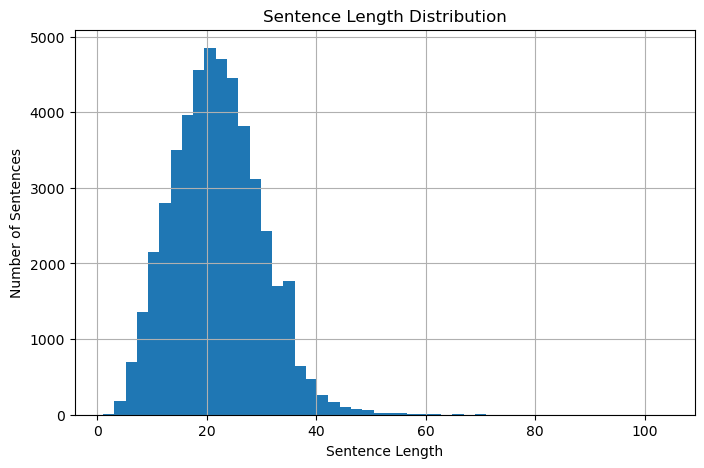

In [36]:
plt.figure(figsize=(8, 5))

plt.hist(
    [len(s) for s in sentences],
    bins=50
)

plt.title("Sentence Length Distribution")
plt.xlabel("Sentence Length")
plt.ylabel("Number of Sentences")

plt.grid(True)
plt.show()

In [37]:
max_len = 50

X_tensors = [
    torch.tensor(seq, dtype=torch.long)
    for seq in X
]

y_tensors = [
    torch.tensor(seq, dtype=torch.long)
    for seq in y
]

pad_input_value = word2idx["ENDPAD"]
pad_label_value = tag2idx["PAD"]

X_pad = pad_sequence(
    X_tensors,
    batch_first=True,
    padding_value=pad_input_value
)

y_pad = pad_sequence(
    y_tensors,
    batch_first=True,
    padding_value=pad_label_value
)

if X_pad.size(1) < max_len:

    pad_amt = max_len - X_pad.size(1)

    X_pad = torch.cat(
        [
            X_pad,
            torch.full(
                (X_pad.size(0), pad_amt),
                pad_input_value,
                dtype=torch.long
            )
        ],
        dim=1
    )

    y_pad = torch.cat(
        [
            y_pad,
            torch.full(
                (y_pad.size(0), pad_amt),
                pad_label_value,
                dtype=torch.long
            )
        ],
        dim=1
    )

else:

    X_pad = X_pad[:, :max_len]
    y_pad = y_pad[:, :max_len]

print("X_pad Shape:", X_pad.shape)
print("y_pad Shape:", y_pad.shape)

X_pad Shape: torch.Size([47959, 50])
y_pad Shape: torch.Size([47959, 50])


In [38]:
dataset_size = X_pad.size(0)

perm = torch.randperm(dataset_size)

train_size = int(0.8 * dataset_size)

train_idx = perm[:train_size]
test_idx = perm[train_size:]

X_train = X_pad[train_idx]
y_train = y_pad[train_idx]

X_test = X_pad[test_idx]
y_test = y_pad[test_idx]

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 38367
Testing Samples: 9592


In [39]:
class NERDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "input_ids": self.X[idx],
            "labels": self.y[idx]
        }


train_loader = DataLoader(
    NERDataset(X_train, y_train),
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    NERDataset(X_test, y_test),
    batch_size=32,
    shuffle=False
)

print("DataLoader Created Successfully!")

DataLoader Created Successfully!


In [40]:
class BiLSTMTagger(nn.Module):

    def __init__(
        self,
        vocab_size,
        tagset_size,
        embedding_dim=50,
        hidden_dim=100,
        dropout=0.1
    ):

        super(BiLSTMTagger, self).__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.dropout = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(
            hidden_dim * 2,
            tagset_size
        )

    def forward(self, x):

        x = self.embedding(x)

        x = self.dropout(x)

        x, _ = self.lstm(x)

        out = self.fc(x)

        return out

In [41]:
vocab_size = len(word2idx) + 1
tagset_size = len(tag2idx)

model = BiLSTMTagger(
    vocab_size=vocab_size,
    tagset_size=tagset_size
).to(device)

print("Model Created Successfully!")
print(model)

Model Created Successfully!
BiLSTMTagger(
  (embedding): Embedding(35180, 50, padding_idx=0)
  (dropout): Dropout(p=0.1, inplace=False)
  (lstm): LSTM(50, 100, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=200, out_features=18, bias=True)
)


In [42]:
loss_fn = nn.CrossEntropyLoss(
    ignore_index=pad_label_value
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss Function:", loss_fn)
print("Optimizer:", optimizer)

Loss Function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [43]:
def train_model(
    model,
    train_loader,
    val_loader,
    loss_fn,
    optimizer,
    epochs=3
):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        model.train()
        total_loss = 0.0

        for batch in train_loader:

            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()

            outputs = model(input_ids)

            loss = loss_fn(
                outputs.view(-1, tagset_size),
                labels.view(-1)
            )

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        model.eval()
        val_loss = 0.0

        with torch.no_grad():

            for batch in val_loader:

                input_ids = batch["input_ids"].to(device)
                labels = batch["labels"].to(device)

                outputs = model(input_ids)

                loss = loss_fn(
                    outputs.view(-1, tagset_size),
                    labels.view(-1)
                )

                val_loss += loss.item()

        train_losses.append(total_loss)
        val_losses.append(val_loss)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {total_loss:.4f} | "
            f"Validation Loss: {val_loss:.4f}"
        )

    return train_losses, val_losses

In [44]:
def evaluate_model(model, test_loader):

    model.eval()

    true_tags = []
    pred_tags = []

    with torch.no_grad():

        for batch in test_loader:

            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids)

            preds = torch.argmax(outputs, dim=-1)

            for i in range(labels.size(0)):

                for j in range(labels.size(1)):

                    lab = labels[i, j].item()

                    if lab != pad_label_value:

                        true_tags.append(idx2tag[lab])

                        pred_tags.append(
                            idx2tag[preds[i, j].item()]
                        )

    return true_tags, pred_tags

In [45]:
true_tags, pred_tags = evaluate_model(
    model,
    test_loader
)

print("Model Evaluation Completed!")
print("Total Predictions:", len(pred_tags))

Model Evaluation Completed!
Total Predictions: 210769


In [46]:
from sklearn.metrics import classification_report

print("\nClassification Report:\n")

print(
    classification_report(
        true_tags,
        pred_tags,
        zero_division=0
    )
)


Classification Report:

              precision    recall  f1-score   support

       B-art       0.00      0.00      0.00        70
       B-eve       0.00      0.16      0.00        70
       B-geo       0.07      0.00      0.00      7592
       B-gpe       0.01      0.01      0.01      3171
       B-nat       0.00      0.03      0.00        29
       B-org       0.03      0.11      0.04      3998
       B-per       0.02      0.00      0.00      3439
       B-tim       0.12      0.05      0.07      4036
       I-art       0.00      0.37      0.00        54
       I-eve       0.00      0.00      0.00        49
       I-geo       0.00      0.00      0.00      1414
       I-gpe       0.00      0.00      0.00        43
       I-nat       0.00      0.44      0.00         9
       I-org       0.01      0.03      0.02      3311
       I-per       0.01      0.00      0.01      3585
       I-tim       0.01      0.10      0.01      1365
           O       0.83      0.06      0.10    178534
  

Epoch 1/3 | Train Loss: 289.1202 | Validation Loss: 55.1504
Epoch 2/3 | Train Loss: 196.9437 | Validation Loss: 44.6722
Epoch 3/3 | Train Loss: 157.6710 | Validation Loss: 40.0970


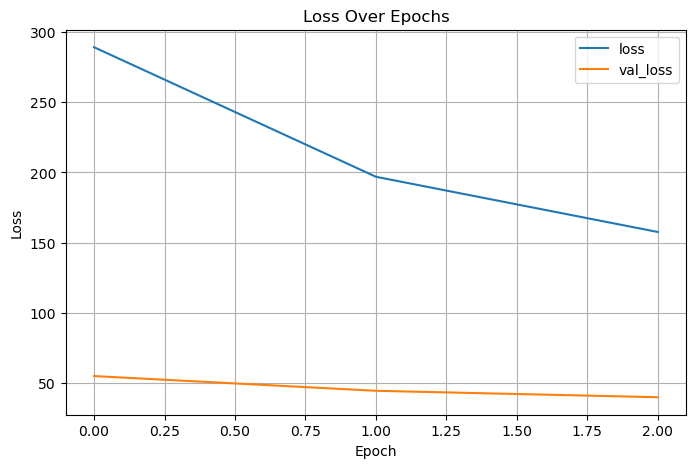

In [48]:


train_losses, val_losses = train_model(
    model,
    train_loader,
    test_loader,
    loss_fn,
    optimizer,
    epochs=3
)



history_df = pd.DataFrame({
    "loss": train_losses,
    "val_loss": val_losses
})

history_df.plot(
    figsize=(8, 5),
    title="Loss Over Epochs"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.show()

In [50]:
sample_idx = 0

model.eval()

sample = X_test[sample_idx].unsqueeze(0).to(device)

with torch.no_grad():
    output = model(sample)
    prediction = torch.argmax(output, dim=-1)

print("=" * 60)
print("             NER PREDICTION RESULT")
print("=" * 60)

for i, word_id in enumerate(X_test[sample_idx]):

    if word_id.item() == pad_input_value:
        continue

    word = words[word_id.item() - 1]

    actual_tag = idx2tag[y_test[sample_idx][i].item()]
    predicted_tag = idx2tag[prediction[0][i].item()]

    print(
        f"{word:<20} "
        f"Actual: {actual_tag:<10} "
        f"Predicted: {predicted_tag}"
    )

print("=" * 60)

             NER PREDICTION RESULT
Pakistan             Actual: B-per      Predicted: B-geo
reached              Actual: O          Predicted: O
a                    Actual: O          Predicted: O
peace                Actual: O          Predicted: O
deal                 Actual: O          Predicted: O
with                 Actual: O          Predicted: O
pro-Taleban          Actual: O          Predicted: O
militants            Actual: O          Predicted: O
in                   Actual: O          Predicted: O
North                Actual: B-geo      Predicted: B-geo
Waziristan           Actual: I-geo      Predicted: I-geo
last                 Actual: O          Predicted: O
year                 Actual: O          Predicted: O
to                   Actual: O          Predicted: O
stop                 Actual: O          Predicted: O
attacks              Actual: O          Predicted: O
on                   Actual: O          Predicted: O
security             Actual: O          Predicted: O